# Ablation: Relation Probability (Rel Prob)

Comparing different relation sampling probabilities:
- **Rel Prob=0.0**: Components only (no relations)
- **Rel Prob=0.25**: Low relation probability
- **Rel Prob=0.5**: Medium relation probability
- **Rel Prob=0.75**: High relation probability
- **Rel Prob=1.0 (Default)**: Full relations (baseline)

The relation probability controls the balance between:
- Component-level negatives (object attributes, colors, etc.)
- Relation-level negatives (spatial relations, actions)

In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [3]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "Rel=0.0": {
        "csv_path": "../evaluation/ablations/31-Dec_coco_with_components_negatives_structured_rel0.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_components_only.csv",
        "is_baseline": False,
        "description": "Components only (no relations)",
        "rel_prob": 0.0
    },
    "Rel=0.25": {
        "csv_path": "../evaluation/ablations/31-Dec_coco_with_components_negatives_structured_rel0.25_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.25.csv",
        "is_baseline": False,
        "description": "Low relation probability",
        "rel_prob": 0.25
    },
    "Rel=0.5": {
        "csv_path": "../evaluation/ablations/31-Dec_coco_with_components_negatives_structured_rel0.5_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.5.csv",
        "is_baseline": False,
        "description": "Medium relation probability",
        "rel_prob": 0.5
    },
    "Rel=0.75": {
        "csv_path": "../evaluation/ablations/31-Dec_coco_with_components_negatives_structured_rel0.75_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_rel_prob_0.75.csv",
        "is_baseline": False,
        "description": "High relation probability",
        "rel_prob": 0.75
    },
    "CS-CLIP (Rel=1.0)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "Full relations (baseline)",
        "rel_prob": 1.0
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "RELATION PROBABILITY ABLATION"
PARAM_KEY = "rel_prob"
PARAM_LABEL = 'Relation Probability'

print("Ablation: Relation Probability")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Relation Probability
  Rel=0.0: Components only (no relations)
  Rel=0.25: Low relation probability
  Rel=0.5: Medium relation probability
  Rel=0.75: High relation probability
  CS-CLIP (Rel=1.0) [BASELINE]: Full relations (baseline)


In [4]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading Rel=0.0...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)
Loading Rel=0.25...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)
Loading Rel=0.5...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 56 datasets (step=15000)
Loading Rel=0.75...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded 56 datasets (step=20000)
Loading CS-CLIP (Rel=1.0)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded 65 datasets (step=15000)

Common datasets (56): ['VG_Relation', 'VG_Attribution', 'ColorFoil', 'SPEC/absolute_size', 'VALSE/actions', 'ControlledImages/COCO-One', 'SugarCrepe/replace_obj', 'SugarCrepe++/swap_object', 'MMVP/State', 'ColorSwap', 'SugarCrepe/replace_att', 'ControlledImages/B', 'MMVP/Spatial', 'SugarCrepe++/swap_atribute', 'VALSE/noun phrases', 'SPEC/existence', 'SugarCrepe++/replace_ob

In [5]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: RELATION PROBABILITY")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: RELATION PROBABILITY
Metric: text_contrastive_accuracy


,VG_Relation,VG_Attribution,ColorFoil,SPEC/absolute_size,VALSE/actions,ControlledImages/COCO-One,SugarCrepe/replace_obj,SugarCrepe++/swap_object,MMVP/State,ColorSwap,SugarCrepe/replace_att,ControlledImages/B,MMVP/Spatial,SugarCrepe++/swap_atribute,VALSE/noun phrases,SPEC/existence,SugarCrepe++/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,VALSE/coreference,SPEC/absolute_spatial,MMVP/Structural Character,ControlledImages/COCO-Two,SugarCrepe/replace_rel,VALSE/relations,NegBench/COCO_val_mcq_llama3.1_rephrased,NegBench/VOC2007_mcq_llama3.1_rephrased,COCO-CF,SugarCrepe++/replace_relation,BLA/co,MMVP/Orientation,VALSE/existence,SPEC/count,NegBench/msr_vtt_mcq_rephrased_llama,ControlledImages/VG-Two,SugarCrepe/swap_obj,SugarCrepe++/replace_attribute,BLA/ap,COLA/multi_objects,MMVP/Color,Flickr30k_Order,ControlledImages/A,SugarCrepe/add_obj,VALSE/counting,SPEC/relative_size,MMVP/Quantity,SPEC/relative_spatial,COCO_Order,Winoground,SugarCrepe/add_att,BLA/rc,VALSE/plurals,MMVP/Presence,MMVP/Camera Perspective,MMVP/Text,VisMin,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Rel=0.0,80.100000,67.500000,89.900000,40.100000,83.700000,46.700000,95.500000,48.600000,13.300000,60.000000,87.600000,34.800000,40.000000,59.800000,93.300000,64.500000,91.600000,74.000000,46.700000,60.600000,12.300000,6.700000,48.000000,73.000000,66.500000,25.800000,30.900000,78.300000,54.800000,48.900000,20.000000,80.800000,33.500000,25.900000,55.000000,64.900000,75.600000,51.100000,37.100000,13.300000,95.900000,31.300000,90.300000,65.900000,30.900000,6.700000,29.700000,94.800000,29.000000,82.700000,48.900000,70.700000,13.300000,6.700000,0.000000,78.700000,52.800000
Rel=0.25,84.500000,68.300000,89.800000,38.100000,85.200000,51.900000,94.900000,50.600000,13.300000,56.300000,87.400000,33.300000,40.000000,60.800000,93.700000,68.500000,91.500000,75.800000,43.400000,55.900000,12.600000,13.300000,49.100000,78.400000,67.300000,29.900000,37.100000,77.800000,61.200000,49.100000,20.000000,84.200000,35.800000,30.400000,53.500000,69.000000,75.900000,50.300000,36.700000,13.300000,96.700000,30.600000,89.900000,66.600000,30.400000,6.700000,29.300000,95.200000,28.500000,81.200000,49.500000,71.300000,0.000000,13.300000,6.700000,78.200000,53.600000
Rel=0.5,83.600000,67.700000,90.200000,38.300000,84.000000,46.800000,95.000000,51.400000,6.700000,56.300000,86.800000,34.800000,26.700000,57.500000,93.100000,68.100000,92.100000,73.900000,43.800000,55.700000,13.200000,13.300000,51.600000,79.100000,69.300000,33.200000,36.700000,78.000000,62.600000,48.300000,20.000000,82.800000,34.500000,29.600000,52.300000,70.200000,74.600000,50.000000,37.100000,13.300000,95.900000,30.600000,90.400000,67.600000,31.900000,6.700000,29.900000,95.400000,28.200000,81.800000,49.200000,70.500000,0.000000,20.000000,0.000000,78.100000,53.200000
Rel=0.75,85.400000,69.300000,89.700000,39.600000,83.600000,49.400000,94.800000,52.700000,6.700000,57.000000,87.300000,32.400000,46.700000,58.900000,93.400000,70.000000,90.900000,74.000000,44.000000,57.500000,12.100000,20.000000,49.800000,79.700000,69.200000,30.400000,36.100000,77.400000,62.900000,47.400000,26.700000,83.200000,35.000000,29.700000,53.100000,71.000000,76.800000,50.900000,38.100000,13.300000,95.700000,32.300000,89.800000,65.600000,31.300000,6.700000,29.600000,95.400000,28.500000,81.600000,49.700000,71.100000,6.700000,13.300000,6.700000,77.400000,54.100000
CS-CLIP (Rel=1.0),86.300000,69.400000,90.500000,38.800000,83.200000,48.000000,94.900000,52.200000,13.300000,59.000000,86.200000,34.600000,46.700000,56.500000,93.700000,68.700000,91.700000,74.500000,45.100000,56.200000,12.200000,6.700000,50.900000,79.700000,70.100000,31.400000,37.800000,78.200000,62.400000,48.400000,13.300000,83.400000,34.500000,29.200000,53.100000,69.000000,74.200000,52.700000,41.000000,13.300000,96.700000,29.100000,90.800000,66.500000,32.700000,6.700000,29.500000,95.300000,29.800000,80.800000,49.600000,70.500000,0.000000,6.700000,13.300000,78.600000,53.700000


In [6]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: RELATION PROBABILITY - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading Rel=0.0...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading Rel=0.25...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading Rel=0.5...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading Rel=0.75...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading CS-CLIP (Rel=1.0)...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (18): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VisMin', 'Winoground']

ABLATION: RELATION PROBABILITY - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
Rel=0.0,61.200000,41.500000,24.900000,42.500000
Rel=0.25,61.800000,41.100000,24.400000,42.500000
Rel=0.5,61.600000,41.000000,23.700000,42.100000
Rel=0.75,62.100000,41.400000,25.000000,42.800000
CS-CLIP (Rel=1.0),62.500000,41.600000,25.400000,43.200000


In [7]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Relation probability ablation. Controls balance between component-level and relation-level negatives. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_relation_prob",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Relation probability ablation. Controls balance between component-level and relation-level negatives. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_relation_prob}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    Rel=0.0 & 61.2 & 41.5 & 24.9 & 42.5 \\
    Rel=0.25 & 61.8 & 41.1 & 24.4 & 42.5 \\
    Rel=0.5 & 61.6 & 41.0 & 23.7 & 42.1 \\
    Rel=0.75 & 62.1 & 41.4 & 25.0 & 42.8 \\
    CS-CLIP (Rel=1.0) & \textbf{\underline{62.5}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{43.2}} \\
    \bottomrule
  \end{tabular}
\end{table}


Saved: ../paper_figures/ablation_relation_prob_bars.pdf


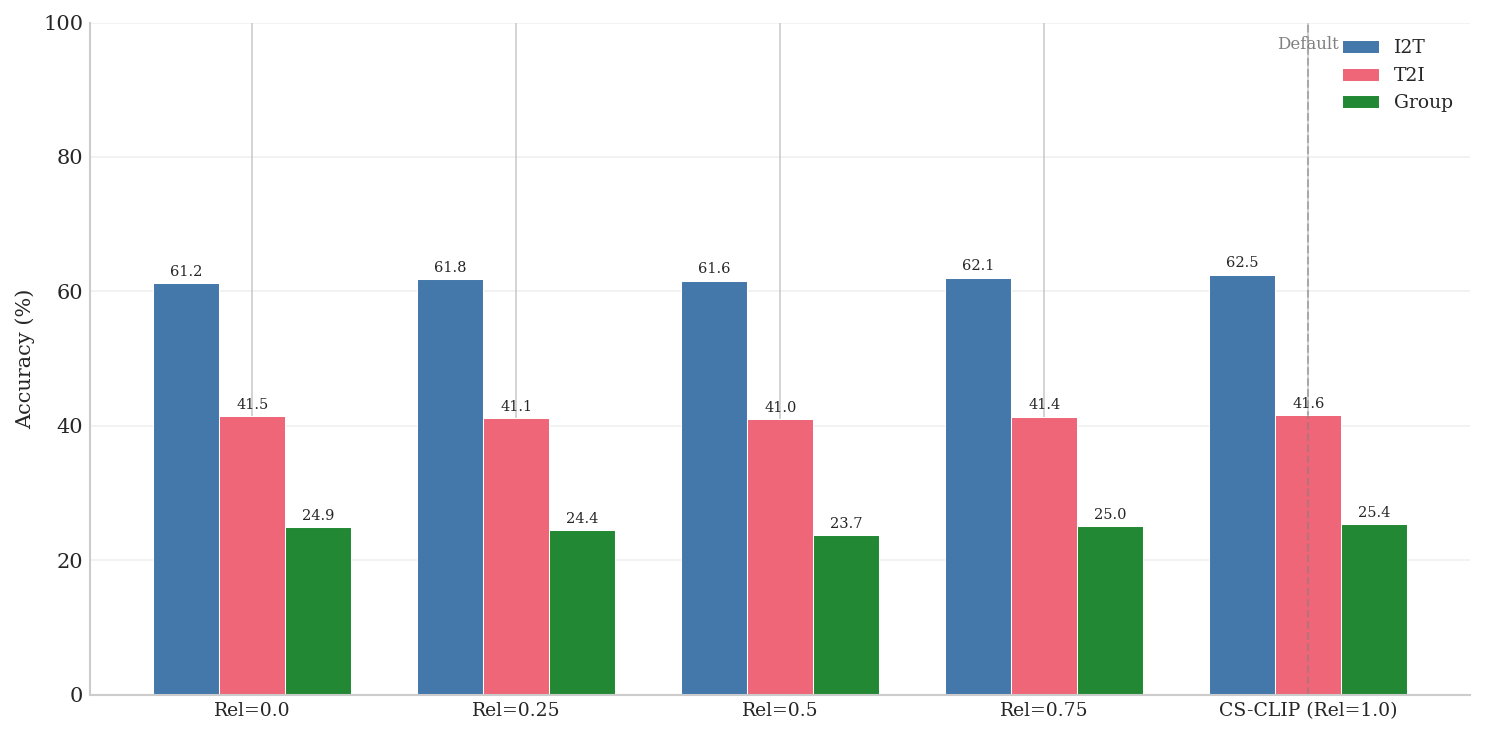

In [9]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Relation Probability Ablation',
    save_path='../paper_figures/ablation_relation_prob_bars.pdf'
)

In [ ]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))

In [ ]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)

In [ ]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)

In [ ]:
# =============================================================================
# SPECIAL ANALYSIS: Relation vs Component Performance
# =============================================================================

# This analysis is particularly interesting for this ablation because:
# - Rel=0 should do better on component-based benchmarks (colors, attributes)
# - Rel=1 should do better on relation-based benchmarks (ARO, spatial)

# Group datasets by type (approximate)
RELATION_DATASETS = ['ARO', 'VALSE', 'Winoground']  # Relation-heavy
COMPONENT_DATASETS = ['ColorFoil', 'ColorSwap', 'BLA']  # Component-heavy

print("\n" + "="*60)
print("RELATION vs COMPONENT PERFORMANCE ANALYSIS")
print("="*60)

# Check if these datasets exist in scores_df
rel_cols = [c for c in scores_df.columns if c in RELATION_DATASETS]
comp_cols = [c for c in scores_df.columns if c in COMPONENT_DATASETS]

if rel_cols:
    print(f"\nRelation-focused datasets: {rel_cols}")
    rel_scores = scores_df[rel_cols].mean(axis=1) * 100
    for model in scores_df.index:
        print(f"  {model}: {rel_scores[model]:.1f}%")

if comp_cols:
    print(f"\nComponent-focused datasets: {comp_cols}")
    comp_scores = scores_df[comp_cols].mean(axis=1) * 100
    for model in scores_df.index:
        print(f"  {model}: {comp_scores[model]:.1f}%")